In [1]:
import model as m
from tensorflow.keras.models import load_model
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import Evaluate_results as er
import matplotlib.pyplot as plt
import seaborn as sns
from keras import backend as K
import tensorflow as tf
import tensorflow as tf
import os
import json
from contextlib import redirect_stdout
import yaml
from matplotlib.colors import ListedColormap
from sklearn.manifold import TSNE
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

2024-03-26 16:56:44.086155: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-26 16:56:44.089254: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-03-26 16:56:44.115676: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-26 16:56:44.115697: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-26 16:56:44.116400: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
dataset_path = 'Data/trainign_dataset_51270_microarray_adjusted.csv'
loss = "Poisson"
optimizer = "adam"
metrics = ["mae"]
epochs = 1500
batch_size = 512
validation_split = 0.2
lasso_alpha = 0.01
two_step_normalization = True


In [3]:
def create_new_folder(base_path="Results"):
    # Check if the Results directory exists, if not, create it
    results_dir = os.path.join(base_path, "Model_outputs")
    if not os.path.exists(results_dir):
        os.makedirs(results_dir)

    # Find existing result folders and determine the next number
    existing_folders = [name for name in os.listdir(results_dir) if os.path.isdir(os.path.join(results_dir, name))]
    if not existing_folders:
        next_number = 1
    else:
        # Sort existing folders to get the highest numbered folder
        existing_folders.sort()
        last_folder = existing_folders[-1]
        last_number = int(last_folder.replace("result", ""))
        next_number = last_number + 1

    # Generate the name for the new folder
    new_folder_name = "result{:02d}".format(next_number)
    new_folder_path = os.path.join(results_dir, new_folder_name)

    # Create the new folder
    os.makedirs(new_folder_path)

    return new_folder_path

In [4]:
def plot_distrobution_features(expression_df, age:list, n_features=None):
    def map_age(age):
        if age == 35:
            return 'Y'
        elif age > 65:
            return 'O'
        else:
            return 'M'
    x = expression_df
    if n_features:
        x=x.sample(n=n_features, axis='columns')
    x["Age"] = age.apply(lambda age: map_age(age))
    data = x
    melted_data = pd.melt(data,id_vars="Age",
                    var_name="features",
                    value_name='value')

    plt.figure(figsize=(10,10))
    sns.violinplot(x="features", y="value", hue="Age", data=melted_data,split=True, inner="quart")
    plt.xticks(rotation=90)


    #sns.boxplot(x="features", y="value", hue="Age", data=melted_data, showfliers=False)
    #plt.xticks(rotation=90)
    return melted_data


In [5]:
def map_to_category(age):
    if age < 35:
        return "Young"
    elif age > 65:
        return "Old"
    else:
        return "MiddleAge"

In [6]:
def color_feature_selction_TSNE(df):
    """
    make sure df has the expression and the column Age
    """
    feature_df = pd.DataFrame(df)
    feature_df_t = pd.DataFrame(df) 
    feature_df_t["Age"]=  [map_to_category(age) for age in df["Age"]] 
    tab20_colors = plt.cm.tab10.colors
    num_colors = len(np.unique(feature_df_t["Age"]))
    colors = [tab20_colors[i] for i in range(num_colors)]
    custom_cmap = ListedColormap(colors)
    ategory_map = {category: i for i, category in enumerate(feature_df_t["Age"])}
    category_map = {'Young': -1, 'MiddleAge': 0, 'Old': 1}
    numeric_age_order = [category_map[experiment] for experiment in feature_df_t["Age"]]
    X = feature_df.drop(columns=["Age"]).values 
    tSNE=TSNE(n_components=2)
    tSNE_result=tSNE.fit_transform(X)
    # Step 3: Visualize the clusters
    # Plot the first two principal components and color them according to the assigned clusters
    x=tSNE_result[:,0]
    y=tSNE_result[:,1]

    plt.figure(figsize=(8, 6))
    plt.scatter(x,y, c=numeric_age_order, cmap=custom_cmap, s=50, alpha=0.5)
    plt.title('TSNE Adjusted')
    #plt.colorbar(label="Experiment", spacing ="uniform",  values=numeric_experiment_order)

    # Create legend with experiment names
    legend_handles = [plt.Line2D([0], [0], marker='o',  markerfacecolor=color, markersize=10, label=f'Experiment {i+1}') for i, color in enumerate(colors)]
    plt.legend(handles=legend_handles, labels=list(category_map.keys()), loc='best')

    #plt.legend(list(category_map.keys()))
    #plt.show()

    plt.savefig(f"{m.output_directory}/TSNE_Scatter_Plot_feature_selection.jpg")

In [7]:
def save_performance_results(results, my_model):
    def analyze_restults(results, my_model):
        results["Experiment"] = my_model.z_test["Experiment"].values
        results["Sample"] = my_model.z_test["Sample"].values
        results["Sex"] = my_model.z_test["Sex"].values
        results["Status"] = my_model.z_test["Status"].values

        results["absolute_error"] = abs(results["Actual"]-results["Predicted"])
        results["big_absolute_error"] = np.where(results["absolute_error"] < 5, 0, results["absolute_error"])
        return results

    results = analyze_restults(results, my_model)
    with open(f"{m.output_directory}/model_summary.txt", "a") as f:
        # Redirect the stdout to the file
        with redirect_stdout(f):
            print("/n/t Actual age distribution:")
            print(results["Actual"].describe())
            print("/n/t Predicted age distribution:")
            print(results["Predicted"].describe())
            print("/n/t Predicted absolute error distribution:")
            print(results["absolute_error"].describe())
            print("/n/n/t /t Is the experiment acting the outcome?/n")
            
            print("/n/t Error distribution absolute_error ~ Experiment anova_lm:")
            print(er.evaluate_error_experiment(results))
            print("/n/t Krustal Wallis test:")
            print (er.evaluate_Kruskal_Wallis(results))
            print("/n/t Dunnes test:")
            print(er.evaluate_Dunnes_test(results))
    er.plot_Dunes_result(er.evaluate_Dunnes_test(results), save=True, file_name=f"{m.output_directory}/Dunnes_test.png")


In [8]:
def run_all():

    m.output_directory=create_new_folder()
    training_data=pd.read_csv(dataset_path)
    my_model = m.Model(training_data)
    normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)
    my_model.train(normalize_X_train=normalized_X_train, 
                    epochs=epochs, optimizer=optimizer,
                    loss=loss, metrics=metrics, batch_size=batch_size, validation_split=validation_split)
    m.plot_model(my_model.model, f'{m.output_directory}/model.png', show_shapes=True)
    results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
    m.print_performance(my_model.history, results, my_model.z_test, save=True)

    conf_dic = {'dataset':dataset_path,
                'loss': loss,
                'optimizer': optimizer,
                'metrics': metrics,
                'epochs': epochs, 
                'batch_size': batch_size, 
                'validation_split': validation_split, 
                'lasso_alpha': lasso_alpha, 
                'two_step_normalization': two_step_normalization}
    with open(f"{m.output_directory}/model_summary.txt", "a") as f:
        # Redirect the stdout to the file
        with redirect_stdout(f):
            print("Error: ")
            print(error)

    save_performance_results(results, my_model)
    clean_df_z = pd.DataFrame(my_model.z_test.values)
    clean_df_z.columns = my_model.z_test.columns
    results_all_metadata = pd.concat([results,clean_df_z ], axis=1)
    with open(f"{m.output_directory}/configuration.yaml", "w") as yaml_file:
        yaml.dump(conf_dic, yaml_file, default_flow_style=False)
    with open(f"{m.output_directory}/model_architecture.yaml", "w") as yaml_file:
        yaml.dump(json.loads(my_model.model.to_json()), yaml_file, default_flow_style=False)
    with open(f"{m.output_directory}/selected_features.csv", "w") as f:
        f.write("\n".join(list(my_model.model_in_features)))

    feature_df = pd.DataFrame(normalized_X_train)
    feature_df = feature_df.dropna()
    feature_df
    feature_df["Age"]= my_model.y_train.values
    color_feature_selction_TSNE(feature_df)
    # Now check with the training data
        
        



In [9]:
dataset_path = 'Data/trainign_dataset_51270_microarray_adjusted.csv'
loss = "mse"
optimizer = "adamW"
metrics = ["mae"]
epochs = 1000
batch_size = 50
validation_split = 0.2
lasso_alpha = 0.05
two_step_normalization = False
    

In [10]:
#run_all()

In [11]:

def my_train_data(X_train, y_train, optimizer='adam', loss='mse', metrics=['mae'], epochs=1500, validation_split=0.1,
              batch_size=50):
    """
    Train the data
    
    :return: The trained model
    """

    n_features = X_train.shape[1]
    new_model = Sequential()

    # Add layers to the model 
    #new_model.add(Dense(8, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
    #new_model.add(Dense(16, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
    #new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
    #new_model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))
    #new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
    #new_model.add(Dense(64, activation='softsign', kernel_initializer='he_normal'))
    new_model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))
    new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
    new_model.add(Dense(16, activation='relu', kernel_initializer='he_normal'))
    new_model.add(Dropout(0.5))
    new_model.add(Dense(8, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
    new_model.add(Dense(1))

    # Compile the model
    new_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    new_model_history = new_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0, validation_split=validation_split)
    return new_model, new_model_history
m.train_data=my_train_data

/tmp/ipykernel_77053/2880560063.py:2: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  training_data=pd.read_csv(dataset_path)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.990e+01, tolerance: 1.000e+01
  model = cd_fast.enet_coordinate_descent(
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE: 18.054
Loss: 405.726
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


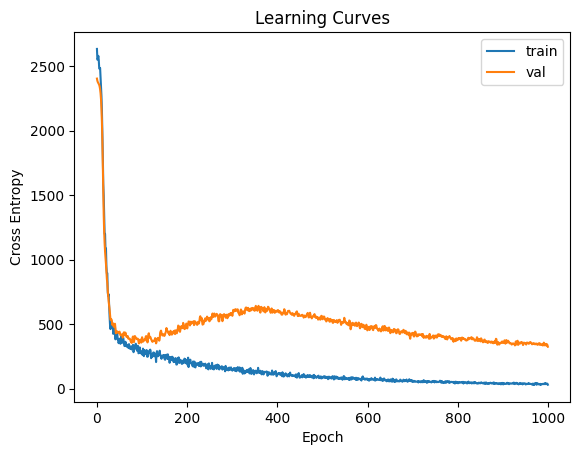

     Actual  Predicted Experiment
0     52.23  29.966646   GSE13070
1     49.76  35.092430   GSE13070
2     66.00  26.661921   GSE48278
3     57.00  37.150436   GSE47969
4     50.43  31.151651   GSE13070
..      ...        ...        ...
142   63.00  30.712471   GSE48278
143   45.11  32.797337   GSE13070
144   53.14  37.431580   GSE13070
145   52.83  30.830019   GSE13070
146   24.12  37.757462   GSE38718

[147 rows x 3 columns]


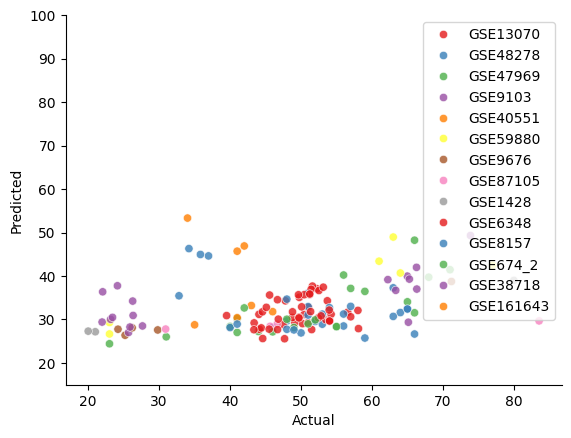

Experiment
GSE13070      48
GSE48278      25
GSE47969      18
GSE9103       13
GSE59880       6
GSE38718       5
GSE9676        5
GSE6348        5
GSE161643      4
GSE674_2       4
GSE87105       4
GSE8157        4
GSE40551       3
GSE1428        3
Name: count, dtype: int64
mae: 18.053525272291534, mse: 407.94570333845115, min: 24.419950485229492, max: 53.32763671875


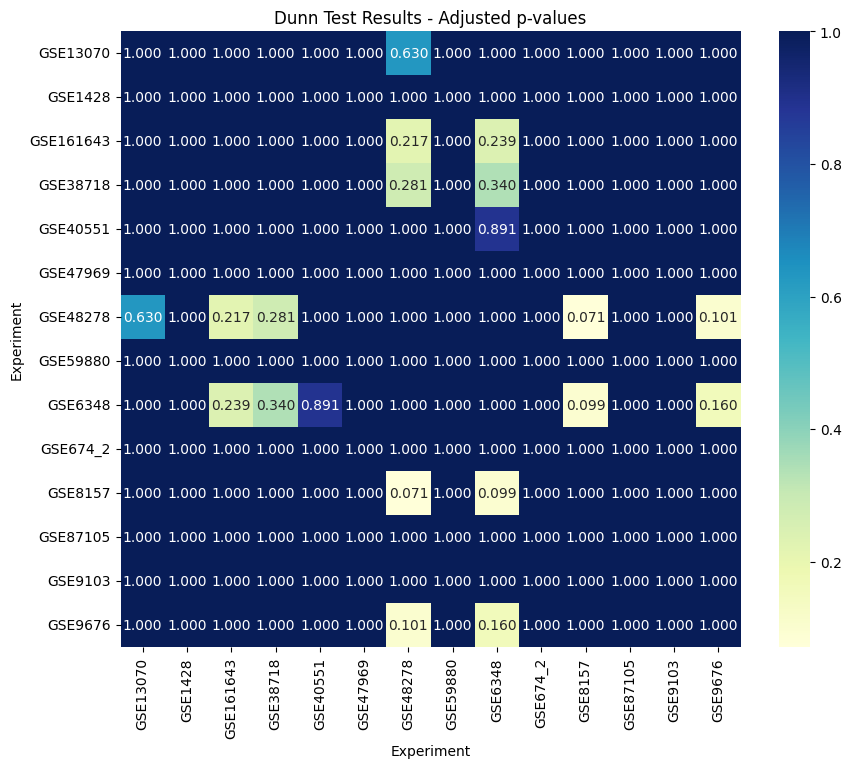

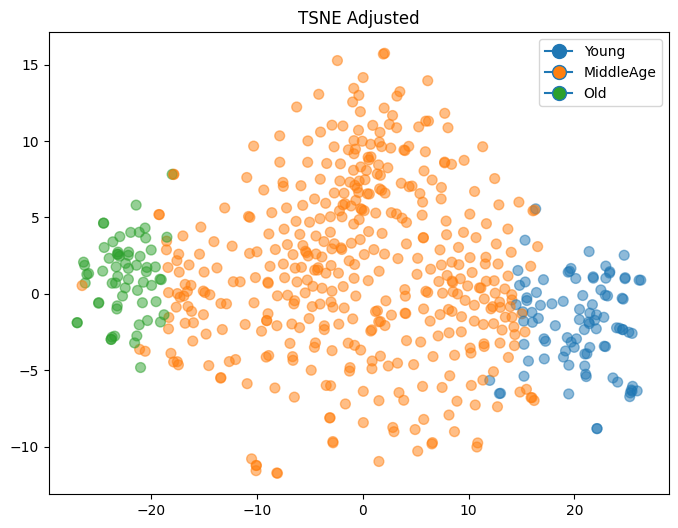

In [241]:

m.output_directory=create_new_folder()
training_data=pd.read_csv(dataset_path)
my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)
my_model.train(normalize_X_train=normalized_X_train, 
                epochs=epochs, optimizer=optimizer,
                loss=loss, metrics=metrics, batch_size=batch_size, validation_split=validation_split)
m.plot_model(my_model.model, f'{m.output_directory}/model.png', show_shapes=True)
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
m.print_performance(my_model.history, results, my_model.z_test, save=True)

conf_dic = {'dataset':dataset_path,
            'loss': loss,
            'optimizer': optimizer,
            'metrics': metrics,
            'epochs': epochs, 
            'batch_size': batch_size, 
            'validation_split': validation_split, 
            'lasso_alpha': lasso_alpha, 
            'two_step_normalization': two_step_normalization}
with open(f"{m.output_directory}/model_summary.txt", "a") as f:
    # Redirect the stdout to the file
    with redirect_stdout(f):
        print("Error: ")
        print(error)

save_performance_results(results, my_model)
clean_df_z = pd.DataFrame(my_model.z_test.values)
clean_df_z.columns = my_model.z_test.columns
results_all_metadata = pd.concat([results,clean_df_z ], axis=1)
results_all_metadata.to_csv(f"{m.output_directory}/results_all_metadata.csv")
with open(f"{m.output_directory}/configuration.yaml", "w") as yaml_file:
    yaml.dump(conf_dic, yaml_file, default_flow_style=False)
with open(f"{m.output_directory}/model_architecture.yaml", "w") as yaml_file:
    yaml.dump(json.loads(my_model.model.to_json()), yaml_file, default_flow_style=False)
with open(f"{m.output_directory}/selected_features.csv", "w") as f:
    f.write("\n".join(list(my_model.model_in_features)))

feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)

Running the Violins of the features already selected

,Age,features,value
0,M,BE504795,-0.862928
1,O,BE504795,0.034530
2,M,BE504795,1.559829
3,M,BE504795,-0.356522
4,O,BE504795,-1.050937
...,...,...,...
8755,M,AL049245,1.229744
8756,M,AL049245,0.038824
8757,M,AL049245,-3.378757
8758,M,AL049245,0.493531


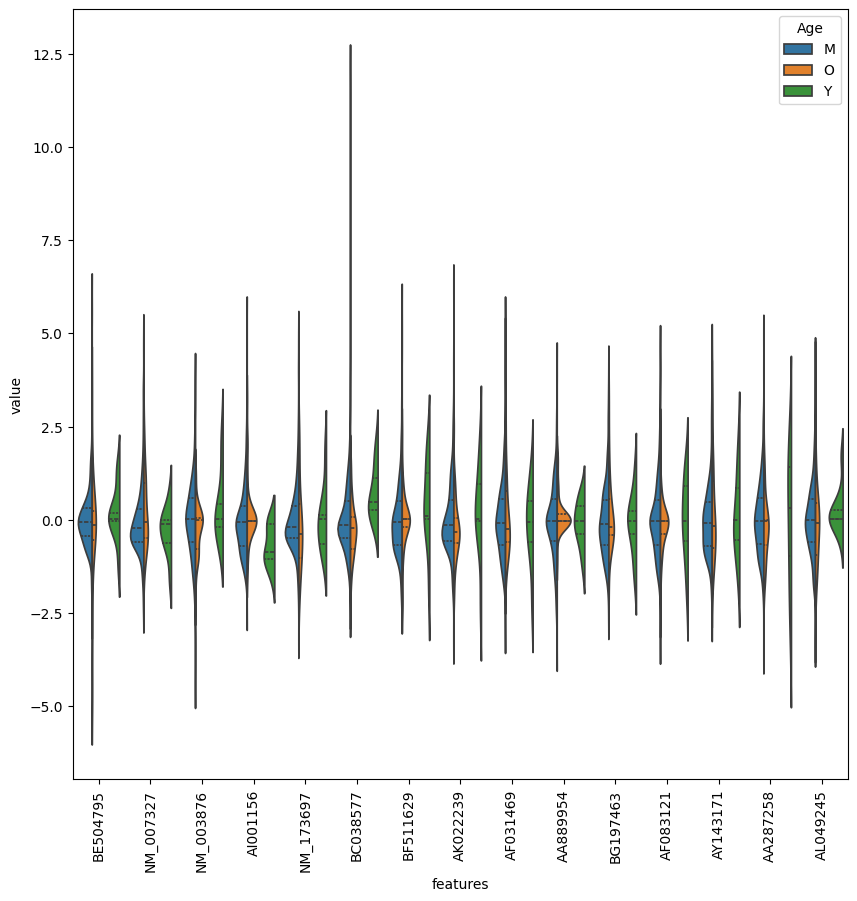

In [212]:
feature_df= pd.DataFrame(normalized_X_train, columns=my_model.model_in_features)
age_df = pd.Series( my_model.y_train.values)
md = plot_distrobution_features(expression_df=feature_df, age=age_df, n_features=15)
md

In [213]:
my_model.y_train


167    47.19
250    78.00
213    46.88
104    44.32
726    65.10
       ...  
268    50.00
485    50.00
358    45.00
415    58.00
694    26.33
Name: Age, Length: 584, dtype: float64

Running the violins on random features

,Age,features,value
0,M,NM_022097,-0.236760
1,M,NM_022097,-0.135345
2,M,NM_022097,-0.262696
3,M,NM_022097,-0.510939
4,NaN,NM_022097,-0.279692
...,...,...,...
8755,M,NM_002006,2.090624
8756,M,NM_002006,-0.233170
8757,M,NM_002006,0.340118
8758,M,NM_002006,-0.057110


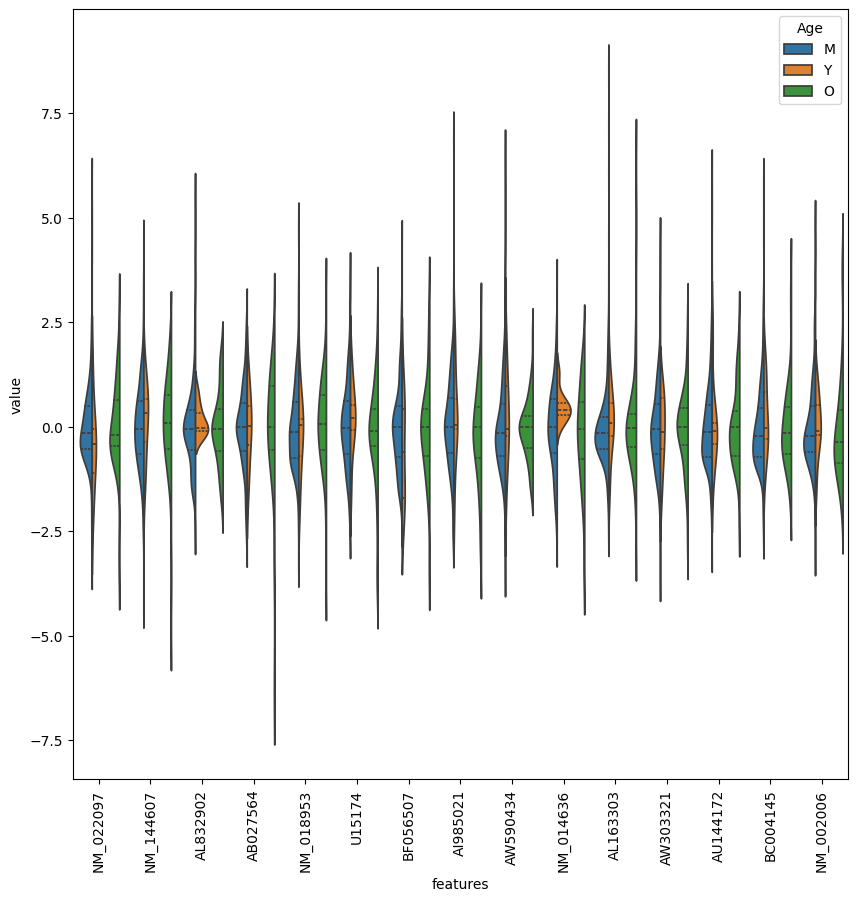

In [214]:
feature_df = pd.DataFrame(my_model.X_train)
age_df = pd.Series( my_model.y_train.values)
md= plot_distrobution_features(expression_df=feature_df, age=age_df, n_features=15)
md

In [215]:
type(my_model.y_train)


pandas.core.series.Series

,Age,features,value
0,M,AW628987,-0.558015
1,O,AW628987,-0.000410
2,M,AW628987,-0.555043
3,M,AW628987,-0.677322
4,O,AW628987,0.001527
...,...,...,...
2915,M,BC033179,1.494420
2916,M,BC033179,-0.366316
2917,M,BC033179,-0.086032
2918,M,BC033179,0.021661


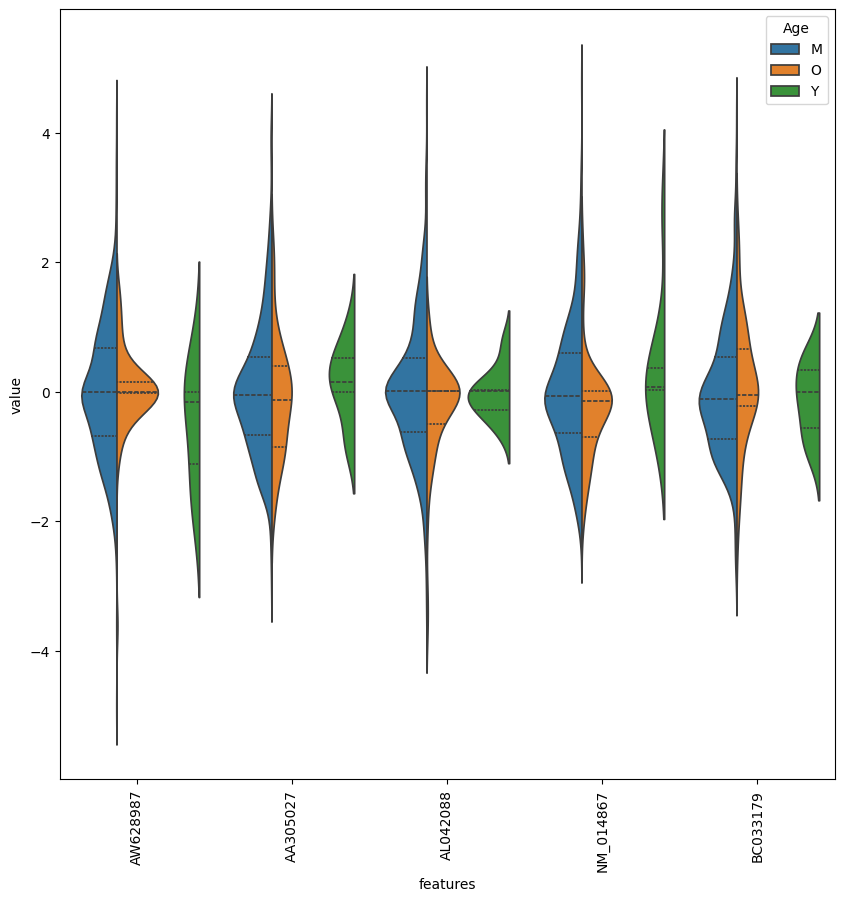

In [216]:
feature_df= pd.DataFrame(normalized_X_train, columns=my_model.model_in_features)
age_df = pd.Series( my_model.y_train.values)
md = plot_distrobution_features(expression_df=feature_df, age=age_df, n_features=5)
md

,Age,features,value
0,M,NM_017614,0.363926
1,M,NM_017614,0.034534
2,M,NM_017614,-1.127744
3,M,NM_017614,0.545430
4,NaN,NM_017614,0.036266
...,...,...,...
2915,M,NM_002085,2.714808
2916,M,NM_002085,-0.123542
2917,M,NM_002085,0.029272
2918,M,NM_002085,0.153046


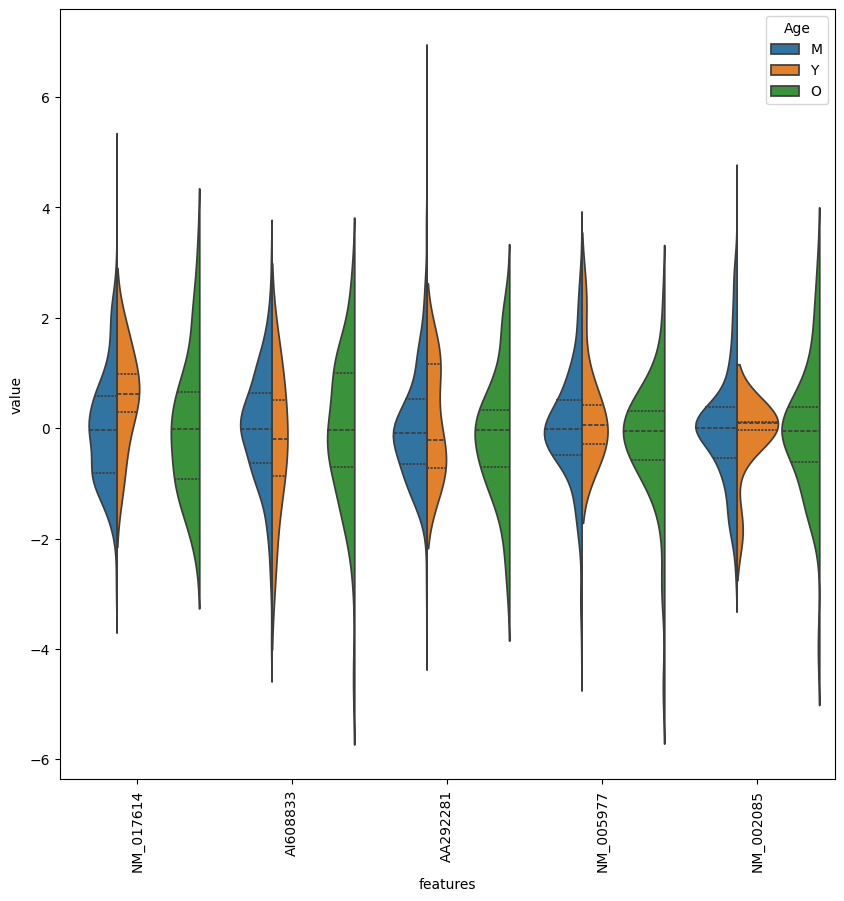

In [217]:
feature_df = pd.DataFrame(my_model.X_train)
age_df = pd.Series( my_model.y_train.values)
md= plot_distrobution_features(expression_df=feature_df, age=age_df, n_features=5)
md

Lets try with clusters; TSNE

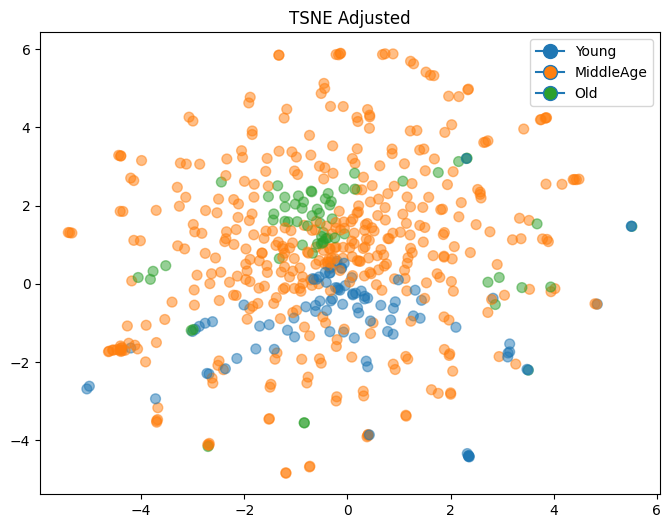

In [218]:
feature_df = pd.DataFrame(my_model.X_train)
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)

In [12]:


feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)

NameError: name 'normalized_X_train' is not defined

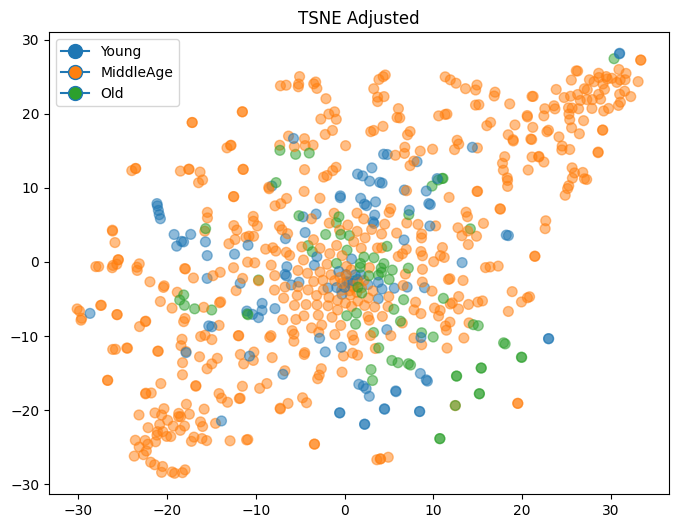

In [220]:
feature_df = pd.DataFrame(training_data)
feature_df = feature_df.drop(columns=['Experiment', 'Sample','Sex', 'Status'])
color_feature_selction_TSNE(feature_df)

In [221]:
training_data.columns

Index(['Sample', 'U48705', 'M87338', 'X51757', 'X69699', 'L36861', 'L13852',
       'X55005', 'X79510', 'M21121',
       ...
       'AI571298', 'AA149545', 'C18318', 'AI219073', 'AI205180', 'AI363375',
       'Experiment', 'Sex', 'Age', 'Status'],
      dtype='object', length=51281)

Using random forest instead

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

def my_evaluate_model(model, X_test, y_test):
    """
    Evaluate the model
    
    :param model: The trained model to evaluate
    :param X_test: The test data
    :param y_test: The test labels
    """
    # Make predictions using the trained model
    predictions = model.predict(X_test)

    # Calculate mean absolute error (MAE)
    mae = mean_absolute_error(y_test, predictions)
    print('MAE: %.3f' % mae)

    # Create a DataFrame to display actual vs predicted values
    results = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})

    return results
m.evaluate_model=my_evaluate_model

In [33]:

def my_train_data(X_train, y_train, n_estimators=500, max_depth=None, min_samples_split=10, min_samples_leaf=20,
                  bootstrap=True):
    """
    Train the data using Random Forest Regressor
    
    :return: The trained model
    """

    # Initialize Random Forest Regressor
    rf_model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                      min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
                                      bootstrap=bootstrap)

    # Fit the model
    rf_model.fit(X_train, y_train)

    return rf_model



/tmp/ipykernel_19911/3314249842.py:3: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  training_data=pd.read_csv(dataset_path)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.990e+01, tolerance: 1.000e+01
  model = cd_fast.enet_coordinate_descent(


MAE: 8.619
     Actual  Predicted Experiment
112   52.23  47.824564   GSE13070
159   49.76  47.847683   GSE13070
547   66.00  47.404444   GSE48278
412   57.00  48.652105   GSE47969
65    50.43  50.680695   GSE13070
..      ...        ...        ...
541   63.00  45.887743   GSE48278
28    45.11  49.046016   GSE13070
44    53.14  51.036708   GSE13070
32    52.83  45.888039   GSE13070
288   24.12  43.045260   GSE38718

[147 rows x 3 columns]


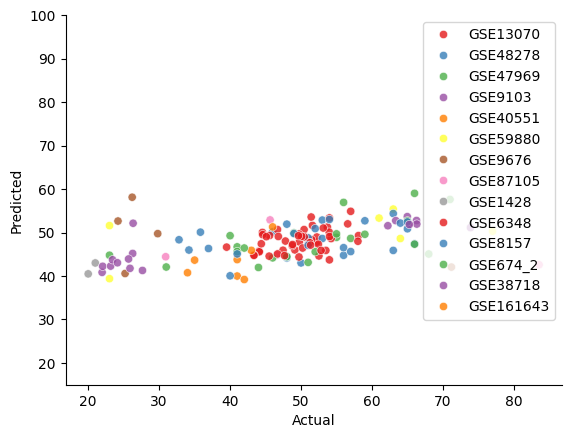

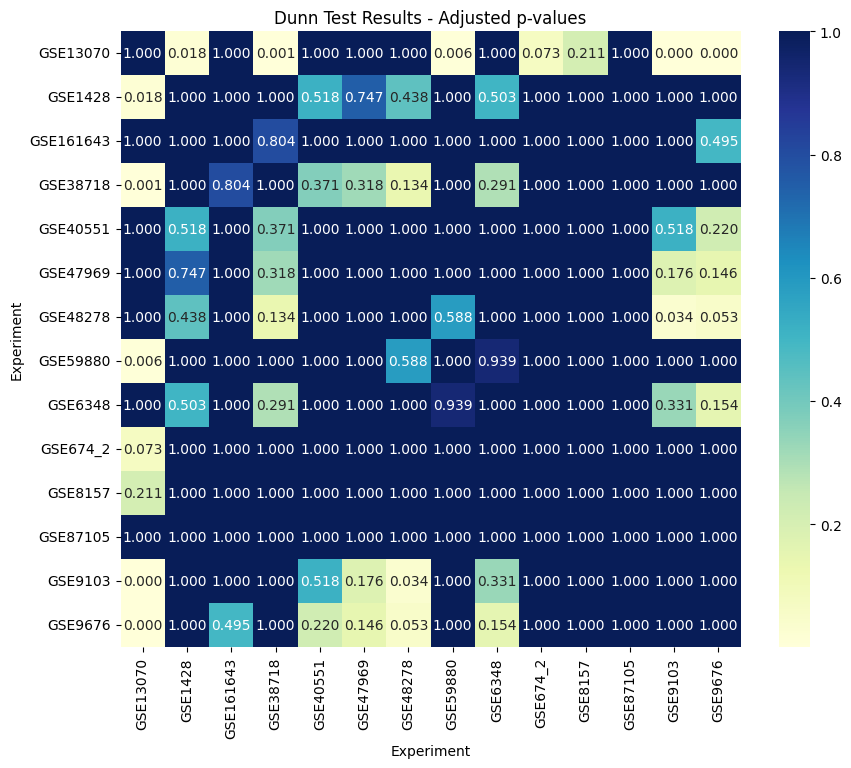

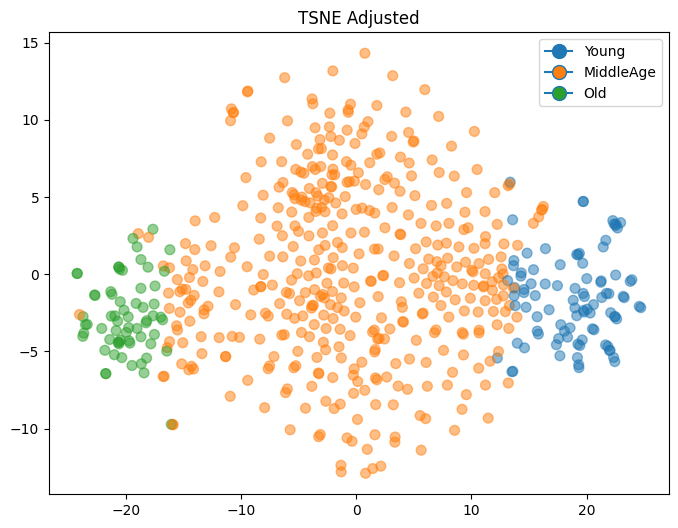

In [35]:
m.train_data=my_train_data
m.output_directory=create_new_folder()
training_data=pd.read_csv(dataset_path)
my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)

my_model.model = m.train_data(X_train=normalized_X_train, y_train=my_model.y_train, n_estimators=400, max_depth=None, min_samples_split=20, min_samples_leaf=20,
                  bootstrap=True)

results = m.evaluate_model(my_model.model, normalized_X_test_fs, my_model.y_test)

m.plot_results(results, my_model.z_test, save=True)

conf_dic = {'dataset':dataset_path,
            'loss': loss,
            'optimizer': optimizer,
            'metrics': metrics,
            'epochs': epochs, 
            'batch_size': batch_size, 
            'validation_split': validation_split, 
            'lasso_alpha': lasso_alpha, 
            'two_step_normalization': two_step_normalization}


save_performance_results(results, my_model)
clean_df_z = pd.DataFrame(my_model.z_test.values)
clean_df_z.columns = my_model.z_test.columns
results_all_metadata = pd.concat([results,clean_df_z ], axis=1)
results_all_metadata.to_csv(f"{m.output_directory}/results_all_metadata.csv")
with open(f"{m.output_directory}/configuration.yaml", "w") as yaml_file:
    yaml.dump(conf_dic, yaml_file, default_flow_style=False)
with open(f"{m.output_directory}/model_architecture.yaml", "w") as yaml_file:
    for param_name, param_value in my_model.model.get_params().items():
            yaml_file.write(f"{param_name}: {param_value}\n")
with open(f"{m.output_directory}/selected_features.csv", "w") as f:
    f.write("\n".join(list(my_model.model_in_features)))

feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)


/tmp/ipykernel_64092/957086457.py:4: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  training_data=pd.read_csv(dataset_path)


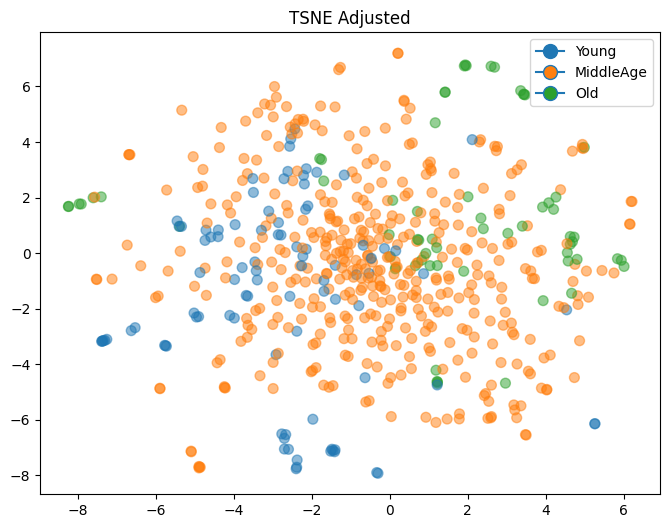

In [16]:
lasso_alpha = 0.9
m.train_data=my_train_data
m.output_directory=create_new_folder()
training_data=pd.read_csv(dataset_path)
my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)


feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)


In [14]:


lasso_alpha

0.05

In [21]:

results

MAE: 8.467


,Actual,Predicted
112,52.23,47.4915
159,49.76,46.8760
547,66.00,48.4103
412,57.00,46.2573
65,50.43,49.5528
...,...,...
541,63.00,46.7216
28,45.11,47.4877
44,53.14,51.1625
32,52.83,46.2103


     Actual  Predicted Experiment      Sample   Sex  \
112   52.23    47.4915   GSE13070   GSM342842  Male   
159   49.76    46.8760   GSE13070   GSM342897  Male   
547   66.00    48.4103   GSE48278  GSM1174146  Male   
412   57.00    46.2573   GSE47969  GSM1163839  Male   
65    50.43    49.5528   GSE13070   GSM342772  Male   
..      ...        ...        ...         ...   ...   
541   63.00    46.7216   GSE48278  GSM1174140  Male   
28    45.11    47.4877   GSE13070   GSM342717  Male   
44    53.14    51.1625   GSE13070   GSM342741  Male   
32    52.83    46.2103   GSE13070   GSM342723  Male   
288   24.12    44.9671   GSE38718   GSM948631  Male   

                                      Status  absolute_error  \
112                                      IRd          4.7385   
159                                IRd � TZD          2.8840   
547  exercise group: F (Resistance exercise)         17.5897   
412                                      NaN         10.7427   
65                 

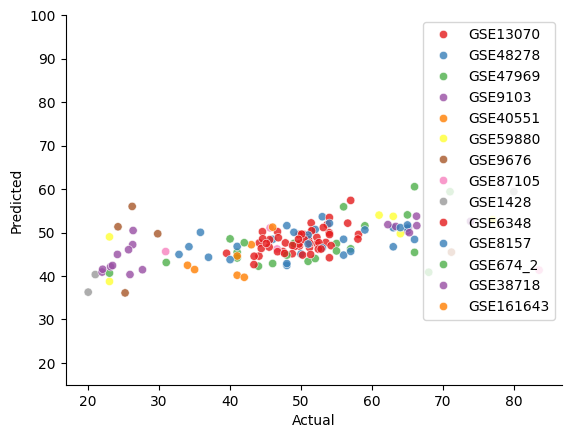

In [30]:
#m.print_performance(my_model.history, results, my_model.z_test, save=True)


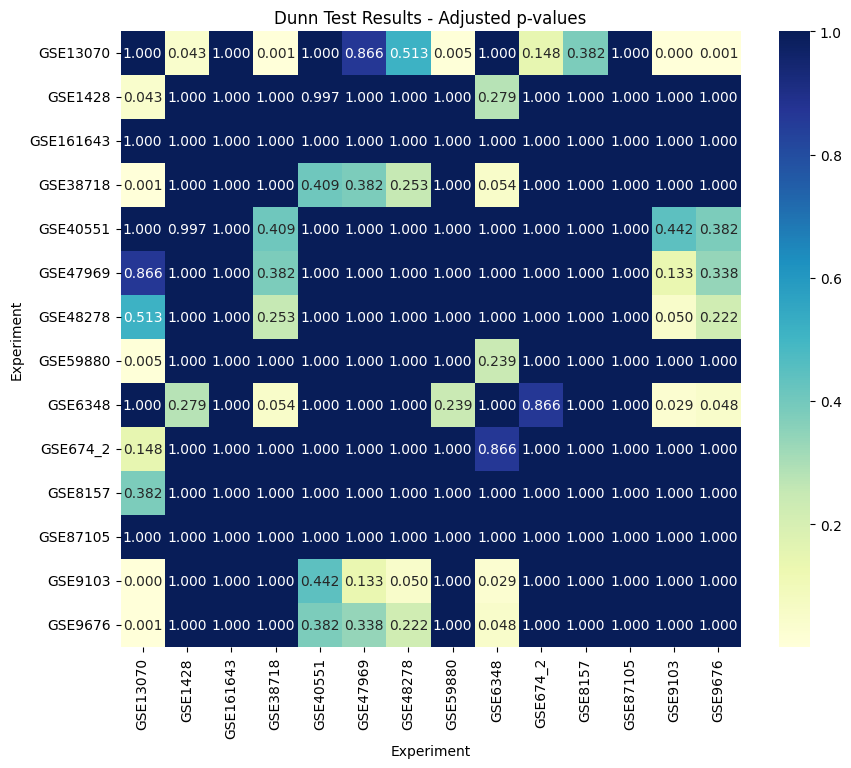

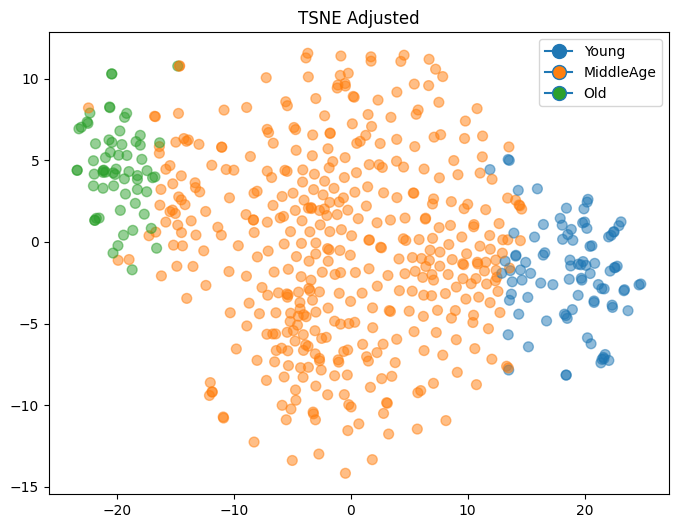